In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data, data.target.rename("HousePrice")],
    axis=1
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Dataset shape:", df.shape)
print(df.isnull().sum())
df.describe()

Dataset shape: (20640, 9)
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

Linear Regression RMSE: 0.7455813830127763
Linear Regression R2: 0.575787706032451


In [8]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_rmse = mean_squared_error(y_test, ridge_pred) ** 0.5
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R2:", ridge_r2)

Ridge Regression RMSE: 0.7455542909384612
Ridge Regression R2: 0.5758185345441319


In [9]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
tree_r2 = r2_score(y_test, test_pred)

print("Decision Tree Train RMSE:", train_rmse)
print("Decision Tree Test RMSE:", test_rmse)
print("Decision Tree R2:", tree_r2)

Decision Tree Train RMSE: 3.0176010694886063e-16
Decision Tree Test RMSE: 0.7021725586639983
Decision Tree R2: 0.6237462423352638


In [10]:
print("Overfitting Analysis:")

if test_rmse > train_rmse:
    print("The Decision Tree is overfitting because train RMSE is very low and test RMSE is higher.")
else:
    print("The Decision Tree is not showing strong overfitting.")

Overfitting Analysis:
The Decision Tree is overfitting because train RMSE is very low and test RMSE is higher.


In [11]:
cv_scores = cross_val_score(
    tree,
    X_scaled,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_rmse_scores = -cv_scores
cv_rmse_mean = cv_rmse_scores.mean()

print("Cross-validation RMSE scores:", cv_rmse_scores)
print("Average CV RMSE:", cv_rmse_mean)

Cross-validation RMSE scores: [0.87752512 0.81754112 0.9051925  0.95581359 0.9247137 ]
Average CV RMSE: 0.8961572070066897


In [12]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV RMSE: 0.6216285193465254


In [13]:
best_tree = grid.best_estimator_

tuned_pred = best_tree.predict(X_test)

tuned_rmse = mean_squared_error(y_test, tuned_pred) ** 0.5
tuned_r2 = r2_score(y_test, tuned_pred)

print("Tuned Decision Tree RMSE:", tuned_rmse)
print("Tuned Decision Tree R2:", tuned_r2)

Tuned Decision Tree RMSE: 0.6389361233642388
Tuned Decision Tree R2: 0.6884641539256358


In [14]:
results = {
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree",
        "Tuned Decision Tree"
    ],
    "RMSE": [
        lr_rmse,
        ridge_rmse,
        test_rmse,
        tuned_rmse
    ],
    "R2 Score": [
        lr_r2,
        ridge_r2,
        tree_r2,
        tuned_r2
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Decision Tree,0.702173,0.623746
3,Tuned Decision Tree,0.638936,0.688464


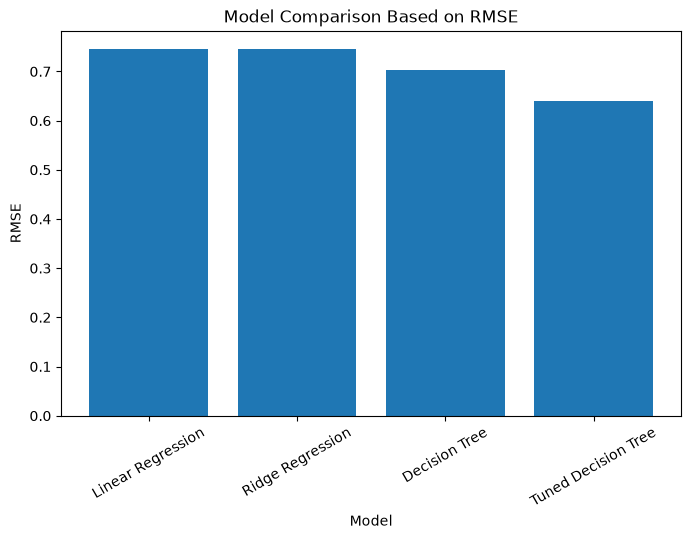

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison Based on RMSE")
plt.xticks(rotation=30)
plt.show()

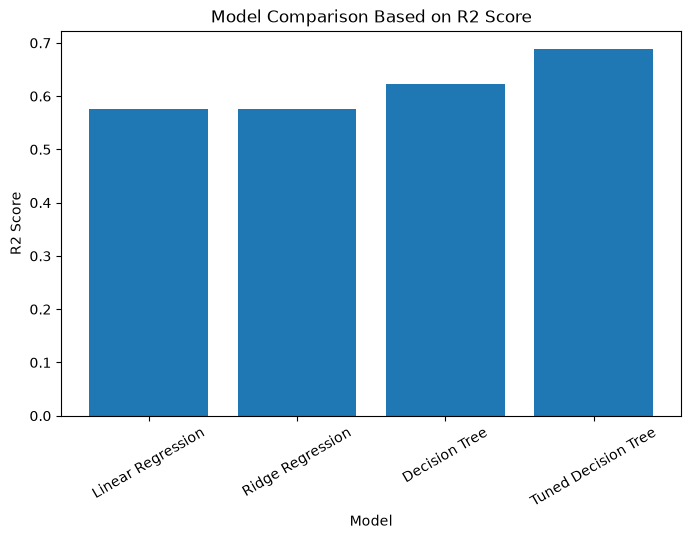

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Model Comparison Based on R2 Score")
plt.xticks(rotation=30)
plt.show()

In [17]:
joblib.dump(best_tree, "final_tuned_decision_tree_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully")

Model and scaler saved successfully


In [18]:
print("""
Final Model Selection Justification:

The tuned Decision Tree model was selected because it controls overfitting better than the default Decision Tree.

The default Decision Tree had very low training error but higher testing error, which shows overfitting. 
GridSearchCV helped select better hyperparameters such as max_depth, min_samples_split, and min_samples_leaf.

Cross-validation was used because it gives more reliable results than a single train-test split.
Linear Regression and Ridge Regression are simple and stable, but they may not capture complex patterns in the data.

The final tuned model gives a good balance between performance and generalization.
""")


Final Model Selection Justification:

The tuned Decision Tree model was selected because it controls overfitting better than the default Decision Tree.

The default Decision Tree had very low training error but higher testing error, which shows overfitting. 
GridSearchCV helped select better hyperparameters such as max_depth, min_samples_split, and min_samples_leaf.

Cross-validation was used because it gives more reliable results than a single train-test split.
Linear Regression and Ridge Regression are simple and stable, but they may not capture complex patterns in the data.

The final tuned model gives a good balance between performance and generalization.

